# ETS MARL - Q-Learning Baseline

This notebook trains and analyses a **tabular Q-learning** baseline for the EU ETS multi-agent environment.

The Q-learning agents use:
- **State discretization**: 5 features x 3 bins = 243 discrete states
- **Action profiles**: 6 auction + 4 secondary = predefined strategy templates
- **Standard Q-learning**: $\alpha=0.1$, $\gamma=0.95$, $\varepsilon$-greedy exploration

This serves as a comparison point for the PPO/HAPPO agents.

## 1. Setup

In [1]:
import os, sys

# Navigate to project root
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

print(f'Working directory: {os.getcwd()}')

Working directory: c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\ets_marl_happo_current


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import time

from src.environment.ets_environment import ETSEnvironment
from src.agents.q_learning_agent import QLearningAgent, StateDiscretizer, ActionProfileMapper
from src.train_qlearning import train_qlearning, evaluate_qlearning, merge_configs
from src.analysis.qlearning_analysis import (
    plot_qtable_heatmaps, plot_secondary_heatmaps,
    plot_strategy_frequency, plot_reward_comparison,
    plot_price_comparison, plot_green_comparison,
    plot_compliance_comparison, load_training_log
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 5)

print('All imports successful.')

All imports successful.


## 2. Load Configuration

In [3]:
with open('configs/default.yaml') as f:
    base_config = yaml.safe_load(f)

with open('configs/qlearning.yaml') as f:
    ql_config = yaml.safe_load(f)

config = merge_configs(base_config, ql_config)

n_agents = config['companies']['n_agents']
n_years = config['simulation']['n_years']
ql_params = config['qlearning']

print(f'Agents: {n_agents} learning + {config["companies"].get("n_bot_agents", 0)} bots')
print(f'Episode length: {n_years} years')
print(f'Q-learning: {ql_params["n_episodes"]} episodes, '
      f'alpha={ql_params["alpha"]}, gamma={ql_params["gamma"]}')
print(f'Epsilon: {ql_params["epsilon_start"]} -> {ql_params["epsilon_end"]} '
      f'over {ql_params["epsilon_decay_frac"]*100:.0f}% of training')
print(f'Reward shaping: beta={config["reward"]["shaping_beta"]}, '
      f'gamma={config["reward"]["shaping_gamma"]} '
      f'(same reward structure as PPO)')

Agents: 8 learning + 4 bots
Episode length: 12 years
Q-learning: 5000 episodes, alpha=0.1, gamma=0.95
Epsilon: 1.0 -> 0.05 over 70% of training
Reward shaping: beta=0.0, gamma=0.0 (disabled for baseline)


## 3. Explore the State/Action Space

Before training, let's understand how the discretizer and action profiles work.

In [4]:
# Show state space structure
disc = StateDiscretizer()
print(f'Total discrete states: {disc.N_STATES}')
print(f'Features and bin edges:')
for name, edges in disc._BINS.items():
    print(f'  {name:10s}: low <= {edges[0]:.2f} | mid <= {edges[1]:.2f} | high')

print(f'\nAction profiles:')
mapper = ActionProfileMapper()
print(f'  Auction ({mapper.N_AUCTION_PROFILES}): {mapper.auction_profile_names()}')
print(f'  Secondary ({mapper.N_SECONDARY_PROFILES}): {mapper.secondary_profile_names()}')
print(f'  Total action combinations: {mapper.N_AUCTION_PROFILES * mapper.N_SECONDARY_PROFILES}')

Total discrete states: 243
Features and bin edges:
  time      : low <= 0.33 | mid <= 0.67 | high
  price     : low <= 0.15 | mid <= 0.40 | high
  green     : low <= 0.35 | mid <= 0.65 | high
  gap       : low <= 0.10 | mid <= 0.60 | high
  cf        : low <= 0.01 | mid <= 0.20 | high

Action profiles:
  Auction (6): ['Conservative', 'Moderate', 'Aggressive', 'GreenPush', 'Financial', 'PanicBuy']
  Secondary (4): ['Hold', 'SellSurplus', 'BuyShortfall', 'AggressiveBuy']
  Total action combinations: 24


In [5]:
# Show what each auction profile produces at a reference price
env_temp = ETSEnvironment(config, seed=42)
env_temp.reset(seed=42)

ref_price = 80.0  # reference MA3 price
company = env_temp.companies[0]  # coal-heavy agent

print(f'Auction profiles at MA3 price = {ref_price} EUR/t (Agent A1: coal-heavy):')
print(f'{"Profile":<15s} {"Bid":>7s} {"Qty":>5s} {"Inv%":>5s} {"Tech":>10s}')
print('-' * 45)
for p_idx in range(6):
    action = mapper.get_auction_action(p_idx, company, ref_price, config)
    tech_idx = np.argmax(action[3:6])
    tech_names = ['onshore', 'offshore', 'solar']
    name = mapper.auction_profile_names()[p_idx]
    print(f'{name:<15s} {action[0]:7.1f} {action[1]:5.2f} {action[2]*100:5.1f} {tech_names[tech_idx]:>10s}')

[ETSEnvironment] 8 learning + 4 bot = 12 total agents | cancel_under_subscribed=False
Auction profiles at MA3 price = 80.0 EUR/t (Agent A1: coal-heavy):
Profile             Bid   Qty  Inv%       Tech
---------------------------------------------
Conservative       72.0  1.00   1.0      solar
Moderate           88.0  1.00   3.0      solar
Aggressive        104.0  1.50   6.0    onshore
GreenPush          96.0  1.00  10.0    onshore
Financial          64.0  0.70   0.0      solar
PanicBuy          120.0  2.00   3.0      solar


## 4. Run a Random-Policy Episode (Pre-training Baseline)

In [6]:
# Run one episode with fully random actions to establish a floor
env = ETSEnvironment(config, seed=42)
agents_random = [QLearningAgent(i, seed=42+i) for i in range(n_agents)]

obs1, _ = env.reset(seed=42)
total_rewards = np.zeros(n_agents)
prices, green_fracs = [], []

for year in range(n_years):
    price_ma3 = env._compute_price_ma3()
    
    # Phase 1 (random)
    auction_actions = np.zeros((n_agents, 6), dtype=np.float32)
    a1_indices = np.zeros(n_agents, dtype=int)
    for i in range(n_agents):
        action, a1_idx = agents_random[i].select_auction_action(
            obs1[i], env.companies[i], price_ma3, config, epsilon=1.0)
        auction_actions[i] = action
        a1_indices[i] = a1_idx
    
    obs2, _ = env.step_auction(auction_actions)
    
    # Phase 2 (random)
    sec_actions = np.zeros((n_agents, 2), dtype=np.float32)
    for i in range(n_agents):
        action, _ = agents_random[i].select_secondary_action(
            obs2[i], env.companies[i], env._phase1_clearing_price,
            config, a1_idx=a1_indices[i], epsilon=1.0)
        sec_actions[i] = action
    
    obs1, rewards, terminated, _, info = env.step_secondary(sec_actions)
    total_rewards += rewards
    
    yl = info.get('year_log', {})
    prices.append(yl.get('clearing_price', 0))
    green_fracs.append([env.companies[i].green_frac for i in range(n_agents)])

print('Random policy episode results:')
print(f'  Total rewards: {["{:.2f}".format(r) for r in total_rewards]}')
print(f'  Final green fracs: {["{:.1f}%".format(env.companies[i].green_frac*100) for i in range(n_agents)]}')
print(f'  Price range: {min(prices):.1f} - {max(prices):.1f} EUR/t')

[ETSEnvironment] 8 learning + 4 bot = 12 total agents | cancel_under_subscribed=False
Random policy episode results:
  Total rewards: ['-11.54', '-2.32', '-15.89', '-1.86', '-2.03', '1.88', '4.17', '3.83']
  Final green fracs: ['58.3%', '51.0%', '85.3%', '99.8%', '84.3%', '100.0%', '100.0%', '100.0%']
  Price range: 70.4 - 118.6 EUR/t


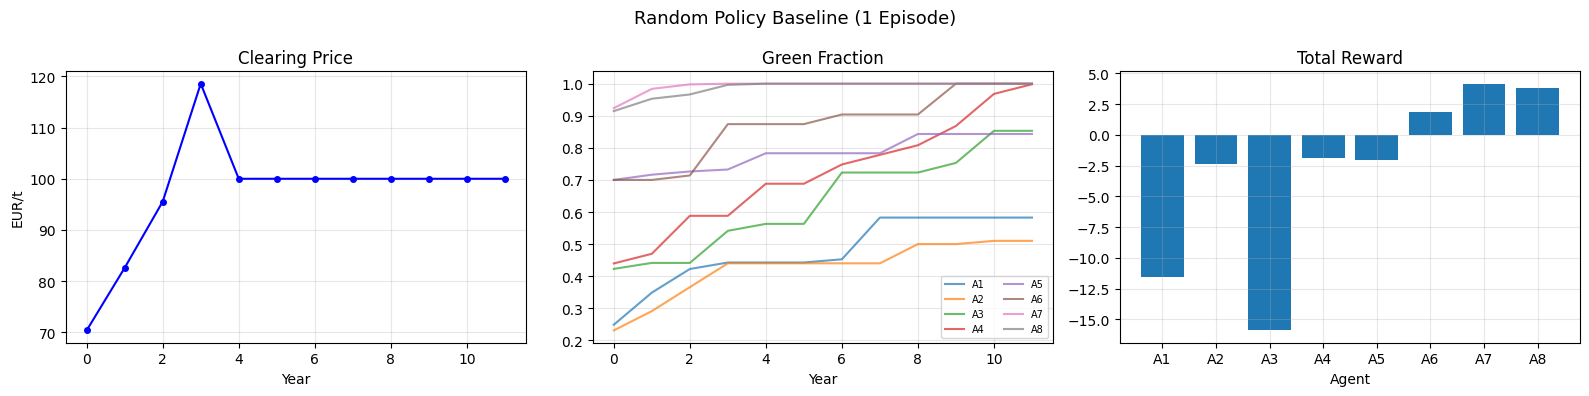

In [7]:
# Plot random episode
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(prices, 'b-o', markersize=4)
axes[0].set_title('Clearing Price')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('EUR/t')
axes[0].grid(True, alpha=0.3)

green_arr = np.array(green_fracs)
for i in range(n_agents):
    axes[1].plot(green_arr[:, i], label=f'A{i+1}', alpha=0.7)
axes[1].set_title('Green Fraction')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

axes[2].bar(range(n_agents), total_rewards)
axes[2].set_title('Total Reward')
axes[2].set_xlabel('Agent')
axes[2].set_xticks(range(n_agents))
axes[2].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
axes[2].grid(True, alpha=0.3)

plt.suptitle('Random Policy Baseline (1 Episode)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Train Q-Learning Agents

Train for 5,000 episodes (adjustable via config). This should take a few minutes.

In [8]:
SEED = 42

# Run training
trained_agents, trained_config = train_qlearning(base_config, ql_config, seed=SEED)


Q-Learning Baseline Training — seed 42
  Episodes: 5000  |  Alpha: 0.1  |  Gamma: 0.95
  Epsilon: 1.00 -> 0.05 over 3500 episodes
  Agents: 8  |  Years/episode: 12
  States: 243  |  Actions: 6×4 profiles

[ETSEnvironment] 8 learning + 4 bot = 12 total agents | cancel_under_subscribed=False
Ep    50/5000 | eps=0.987 | price=103.3 | elapsed=0:00:05 ETA=0:07:46
  A1: rew=  -9.47  green= 46.3%  comply= 91.2%  short=4.406Mt
  A2: rew=  -8.23  green= 46.4%  comply= 91.3%  short=3.411Mt
  A3: rew=  -4.28  green= 66.0%  comply= 89.5%  short=3.158Mt
  A4: rew=  -6.68  green= 66.6%  comply= 83.3%  short=5.624Mt
  A5: rew=  -0.14  green= 96.8%  comply= 80.2%  short=2.644Mt
  A6: rew=  -0.10  green= 96.3%  comply= 84.0%  short=2.337Mt
  A7: rew=  +2.33  green=100.0%  comply= 70.5%  short=1.779Mt
  A8: rew=  +2.95  green=100.0%  comply= 78.3%  short=1.151Mt

Ep   100/5000 | eps=0.973 | price=104.8 | elapsed=0:00:09 ETA=0:07:42
  A1: rew= -11.32  green= 42.4%  comply= 86.5%  short=5.696Mt
  A2: rew

## 6. Training Curves

In [8]:
import glob
import re

# Resolve results directory even if Section 5 was run on another device
if 'trained_config' in globals() and isinstance(trained_config, dict):
    results_dir = trained_config.get('logging', {}).get('results_dir', 'results/qlearning/')
else:
    results_dir = 'results/qlearning/'

# Find training logs; prefer the current SEED if available
log_pattern = os.path.join(results_dir, 'ql_training_log_s*.csv')
log_candidates = glob.glob(log_pattern)

if not log_candidates:
    # Fallback: search recursively under results/
    log_candidates = glob.glob(os.path.join('results', '**', 'ql_training_log_s*.csv'), recursive=True)

if not log_candidates:
    raise FileNotFoundError(
        "No Q-learning training log found. Expected files like 'ql_training_log_s42.csv'."
    )

def _seed_from_path(path):
    m = re.search(r'ql_training_log_s(\d+)\.csv$', path.replace('\\', '/'))
    return int(m.group(1)) if m else -1

preferred_seed = globals().get('SEED', None)
if preferred_seed is not None:
    matching = [p for p in log_candidates if _seed_from_path(p) == preferred_seed]
else:
    matching = []

if matching:
    log_path = matching[0]
else:
    # Use latest modified log if preferred seed is unavailable
    log_path = max(log_candidates, key=os.path.getmtime)

ACTIVE_SEED = _seed_from_path(log_path)
SEED = ACTIVE_SEED  # keep downstream cells consistent
results_dir = os.path.dirname(log_path) or results_dir

ql_df = pd.read_csv(log_path)

print(f'Training log loaded: {log_path}')
print(f'Active seed: {ACTIVE_SEED}')
print(f'Training log: {len(ql_df)} episodes')
print(f'Columns: {list(ql_df.columns)[:10]}...')

# Optional artifact: Q-tables
qtable_candidates = []
qtable_pref = os.path.join(results_dir, f'qtables_s{ACTIVE_SEED}_final.npz')
if os.path.exists(qtable_pref):
    qtable_candidates = [qtable_pref]
else:
    qtable_candidates = glob.glob(os.path.join(results_dir, 'qtables_s*_final.npz'))

HAS_QTABLES = len(qtable_candidates) > 0
qtables = None
qtable_path = None
if HAS_QTABLES:
    qtable_path = qtable_candidates[0]
    qtables = dict(np.load(qtable_path, allow_pickle=False))
    print(f'Q-tables loaded: {qtable_path}')
else:
    print('Q-tables not found. Q-table analysis and evaluation cells will be skipped.')

# Build evaluation inputs if possible
EVAL_AGENTS = None
EVAL_CONFIG = None

if 'trained_agents' in globals() and 'trained_config' in globals():
    EVAL_AGENTS = trained_agents
    EVAL_CONFIG = trained_config
    print('Evaluation source: in-memory trained_agents/trained_config')
else:
    # Rebuild config from YAML (works when notebook restarted on another machine)
    if 'config' not in globals():
        with open('configs/default.yaml') as f:
            _base = yaml.safe_load(f)
        with open('configs/qlearning.yaml') as f:
            _ql = yaml.safe_load(f)
        config = merge_configs(_base, _ql)
    EVAL_CONFIG = config

    if HAS_QTABLES:
        n_agents_local = EVAL_CONFIG['companies']['n_agents']
        ql_params_local = EVAL_CONFIG.get('qlearning', {})
        restored_agents = [
            QLearningAgent(
                i,
                alpha=ql_params_local.get('alpha', 0.1),
                gamma=ql_params_local.get('gamma', 0.95),
                seed=ACTIVE_SEED + i,
            )
            for i in range(n_agents_local)
        ]
        for i in range(n_agents_local):
            key = f'agent_{i}'
            if key in qtables:
                restored_agents[i].q_table = qtables[key]
        EVAL_AGENTS = restored_agents
        print('Evaluation source: agents reconstructed from saved Q-tables + YAML config')

ql_df.tail(3)

Training log loaded: results/qlearning\ql_training_log_s42.csv
Active seed: 42
Training log: 5000 episodes
Columns: ['episode', 'epsilon', 'clearing_price_last', 'cap_last', 'reward_A1', 'green_frac_A1', 'compliance_rate_A1', 'shortfall_A1', 'a1_profile_A1', 'a2_profile_A1']...
Q-tables loaded: results/qlearning\qtables_s42_final.pkl
Evaluation source: agents reconstructed from saved Q-tables + YAML config


,episode,epsilon,clearing_price_last,cap_last,reward_A1,green_frac_A1,compliance_rate_A1,shortfall_A1,a1_profile_A1,a2_profile_A1,...,a2_profile_A7,reward_A8,green_frac_A8,compliance_rate_A8,shortfall_A8,a1_profile_A8,a2_profile_A8,secondary_volume,mean_price,tnac
4997,4997,0.05,100.0,26.29,-3.79,0.422,1.0,0.0,1,0,...,1,3.69,1.0,1.0,0.0,5,1,76.33,98.0,38.35
4998,4998,0.05,100.0,26.29,-4.40,0.340,1.0,0.0,4,3,...,3,4.05,1.0,1.0,0.0,5,1,67.09,93.3,38.99
4999,4999,0.05,100.0,26.29,-6.18,0.268,1.0,0.0,1,2,...,3,3.87,1.0,1.0,0.0,5,1,79.41,92.8,33.13


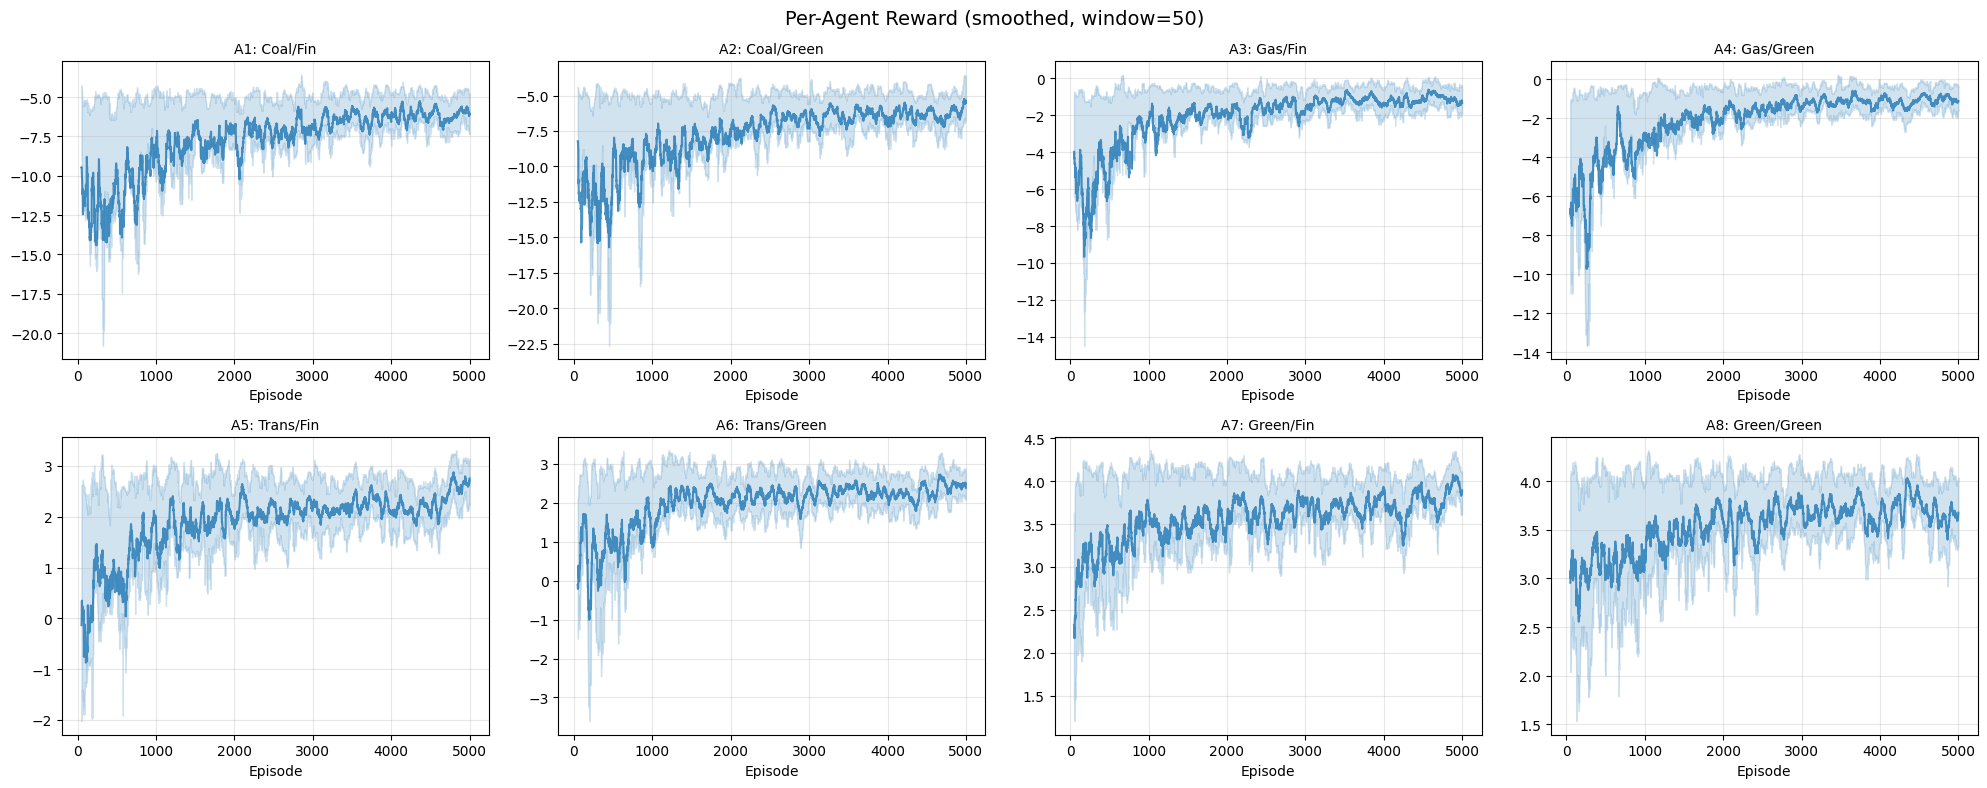

In [9]:
# Reward curves
window = 50
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(f'Per-Agent Reward (smoothed, window={window})', fontsize=14)

archetypes = ['Coal/Fin', 'Coal/Green', 'Gas/Fin', 'Gas/Green',
              'Trans/Fin', 'Trans/Green', 'Green/Fin', 'Green/Green']

for i in range(n_agents):
    ax = axes[i // 4, i % 4]
    col = f'reward_A{i+1}'
    rewards = ql_df[col].astype(float).values
    smoothed = pd.Series(rewards).rolling(window).mean()
    ax.plot(smoothed, color='tab:blue', alpha=0.8)
    ax.fill_between(range(len(smoothed)),
                    pd.Series(rewards).rolling(window).quantile(0.25),
                    pd.Series(rewards).rolling(window).quantile(0.75),
                    alpha=0.2, color='tab:blue')
    ax.set_title(f'A{i+1}: {archetypes[i]}', fontsize=10)
    ax.set_xlabel('Episode')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

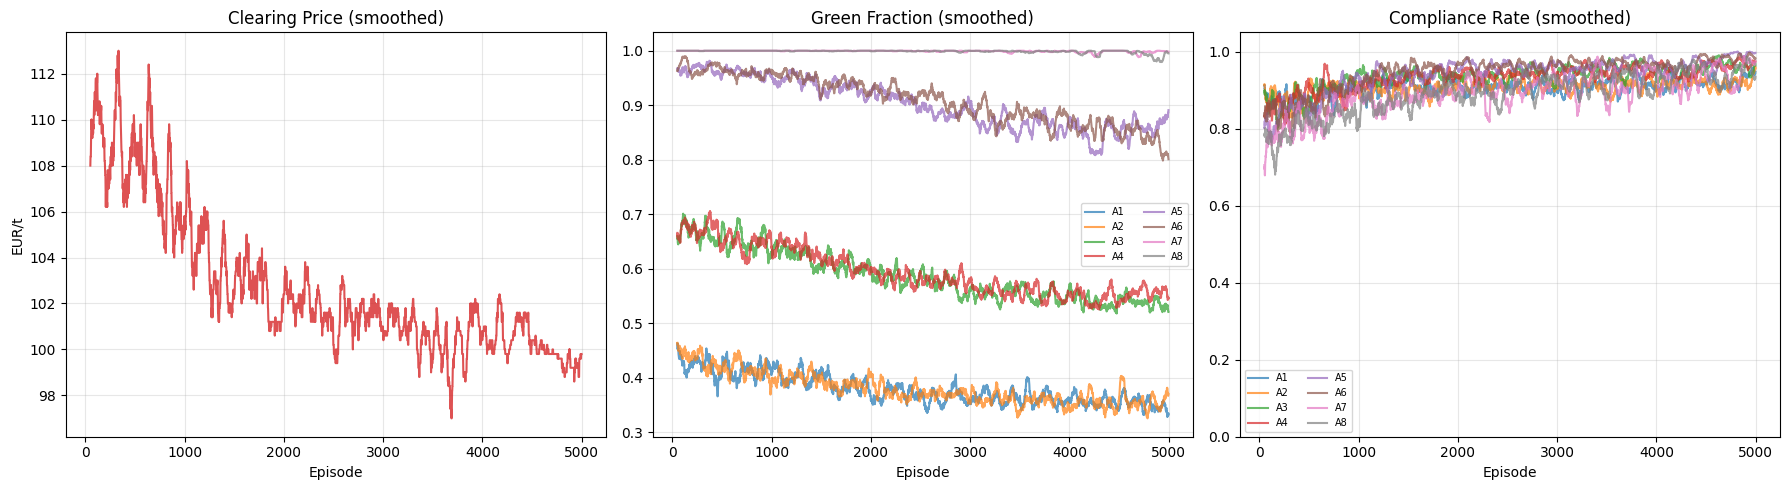

In [10]:
# Price and green fraction trajectories
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Price
prices = ql_df['clearing_price_last'].astype(float)
axes[0].plot(prices.rolling(window).mean(), color='tab:red', alpha=0.8)
axes[0].set_title('Clearing Price (smoothed)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('EUR/t')
axes[0].grid(True, alpha=0.3)

# Green fractions
for i in range(n_agents):
    col = f'green_frac_A{i+1}'
    gf = ql_df[col].astype(float)
    axes[1].plot(gf.rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
axes[1].set_title('Green Fraction (smoothed)')
axes[1].set_xlabel('Episode')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

# Compliance
for i in range(n_agents):
    col = f'compliance_rate_A{i+1}'
    cr = ql_df[col].astype(float)
    axes[2].plot(cr.rolling(window).mean(), label=f'A{i+1}', alpha=0.7)
axes[2].set_title('Compliance Rate (smoothed)')
axes[2].set_xlabel('Episode')
axes[2].legend(fontsize=7, ncol=2)
axes[2].set_ylim(0, 1.05)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Q-Table Analysis

In [11]:
# Load final Q-tables (already loaded in Cell 15)
if HAS_QTABLES and qtables is not None:
    print(f'Loaded Q-tables for {len(qtables)} agents from: {qtable_path}')
    for key, qt in qtables.items():
        nonzero = np.count_nonzero(qt)
        total = qt.size
        print(f'  {key}: shape={qt.shape}, '
              f'non-zero={nonzero}/{total} ({nonzero/total*100:.1f}%), '
              f'Q range=[{qt.min():.3f}, {qt.max():.3f}]')
else:
    print('No Q-tables available. Skipping Section 7 plots and top-Q analysis.')

Loaded Q-tables for 8 agents from: results/qlearning\qtables_s42_final.pkl
  agent_0: shape=(243, 6, 4), non-zero=827/5832 (14.2%), Q range=[-9.201, 0.793]
  agent_1: shape=(243, 6, 4), non-zero=825/5832 (14.1%), Q range=[-8.932, 1.040]
  agent_2: shape=(243, 6, 4), non-zero=655/5832 (11.2%), Q range=[-5.627, 1.324]
  agent_3: shape=(243, 6, 4), non-zero=666/5832 (11.4%), Q range=[-5.960, 1.254]
  agent_4: shape=(243, 6, 4), non-zero=478/5832 (8.2%), Q range=[-1.488, 2.193]
  agent_5: shape=(243, 6, 4), non-zero=474/5832 (8.1%), Q range=[-1.664, 2.150]
  agent_6: shape=(243, 6, 4), non-zero=427/5832 (7.3%), Q range=[-0.462, 3.128]
  agent_7: shape=(243, 6, 4), non-zero=433/5832 (7.4%), Q range=[-0.378, 3.114]


c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\ets_marl_happo_current\src\analysis\qlearning_analysis.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


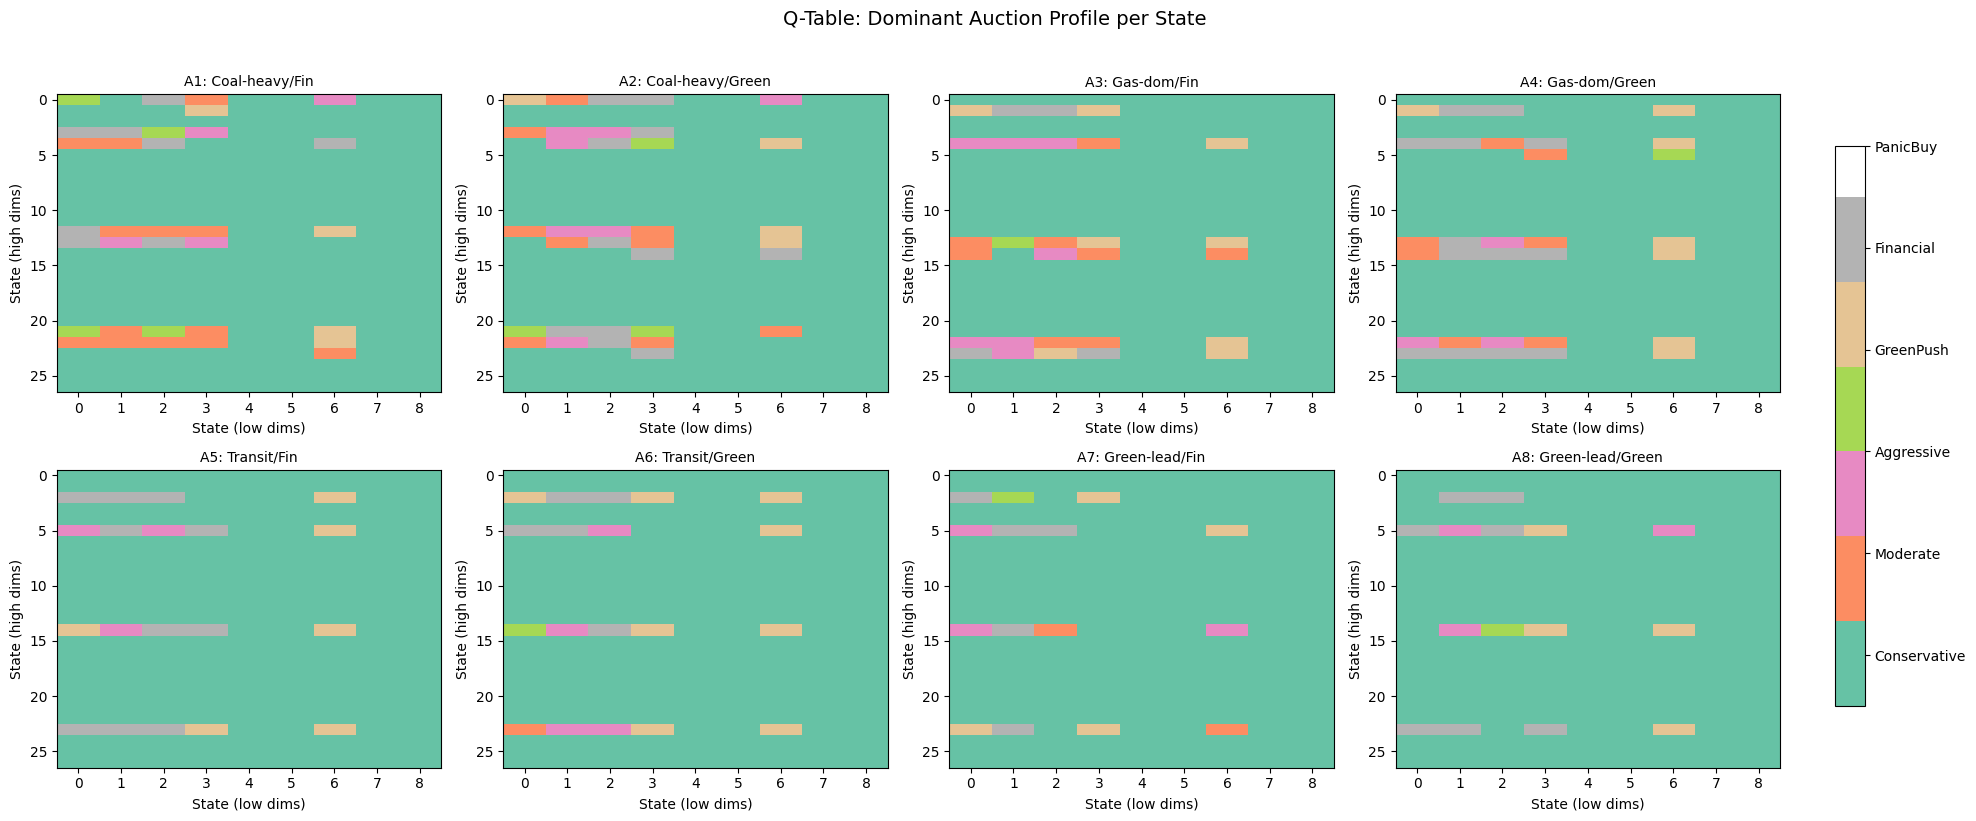

In [12]:
# Q-table heatmaps: dominant auction profile per state
if HAS_QTABLES and qtables is not None:
    plot_qtable_heatmaps(qtables, n_agents)
    plt.show()
else:
    print('Skipped: Q-tables not available.')

c:\Users\danie\Documents\Python_Scripts\Master Thesis\Thesis-Energy-Auction\ets_marl_happo_current\src\analysis\qlearning_analysis.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 1.0])


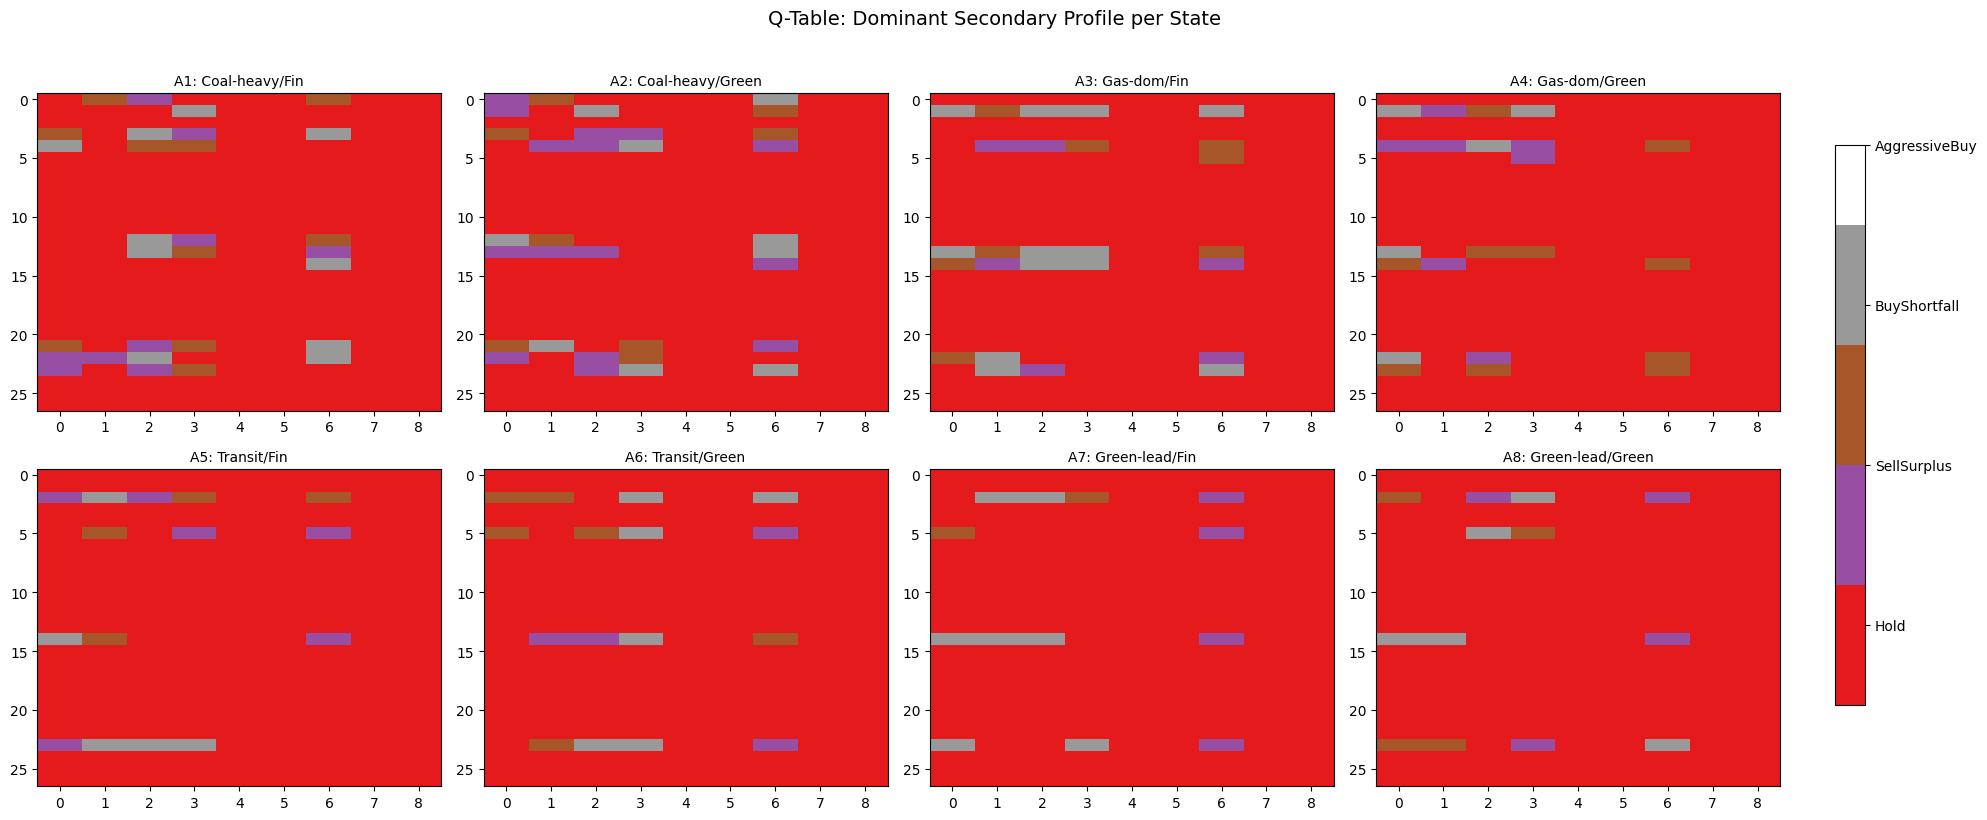

In [13]:
# Q-table heatmaps: dominant secondary profile per state
if HAS_QTABLES and qtables is not None:
    plot_secondary_heatmaps(qtables, n_agents)
    plt.show()
else:
    print('Skipped: Q-tables not available.')

In [14]:
# Top-5 Q-values per agent (works with saved Q-tables, no in-memory agents required)
if HAS_QTABLES and qtables is not None:
    a1_names = ActionProfileMapper.auction_profile_names()
    a2_names = ActionProfileMapper.secondary_profile_names()
    disc = StateDiscretizer()

    for i in range(n_agents):
        key = f'agent_{i}'
        if key not in qtables:
            print(f'\nA{i+1}: Q-table missing ({key})')
            continue

        qt = qtables[key]  # expected shape: [state, auction_profile, secondary_profile]
        k = 5
        flat = qt.reshape(-1)
        top_idx = np.argpartition(flat, -k)[-k:]
        top_idx = top_idx[np.argsort(flat[top_idx])[::-1]]

        print(f'\nA{i+1} ({archetypes[i]}) — Top 5 Q-values:')
        for idx in top_idx:
            s, a1, a2 = np.unravel_index(idx, qt.shape)
            qval = qt[s, a1, a2]
            bins = disc.index_to_bins(int(s))
            state_desc = ', '.join([['early','mid','late'][bins[0]],
                                    ['lowP','medP','highP'][bins[1]],
                                    ['dirty','mixed','green'][bins[2]],
                                    ['deficit','balanced','surplus'][bins[3]],
                                    ['noCF','someCF','heavyCF'][bins[4]]])
            print(f'  Q={qval:+.3f} | state=({state_desc}) | '
                  f'auction={a1_names[a1]} | secondary={a2_names[a2]}')
else:
    print('Skipped: Q-tables not available.')


A1 (Coal/Fin) — Top 5 Q-values:
  Q=+0.793 | state=(late, medP, green, surplus, noCF) | auction=Moderate | secondary=Hold
  Q=+0.614 | state=(late, medP, green, surplus, noCF) | auction=Aggressive | secondary=AggressiveBuy
  Q=+0.389 | state=(late, medP, green, surplus, noCF) | auction=Financial | secondary=SellSurplus
  Q=+0.349 | state=(late, medP, green, surplus, noCF) | auction=GreenPush | secondary=SellSurplus
  Q=+0.333 | state=(late, medP, green, surplus, noCF) | auction=Conservative | secondary=AggressiveBuy

A2 (Coal/Green) — Top 5 Q-values:
  Q=+1.040 | state=(late, medP, green, surplus, noCF) | auction=Conservative | secondary=AggressiveBuy
  Q=+0.660 | state=(late, medP, green, surplus, noCF) | auction=Conservative | secondary=SellSurplus
  Q=+0.600 | state=(late, medP, green, surplus, noCF) | auction=Financial | secondary=SellSurplus
  Q=+0.479 | state=(late, medP, green, surplus, noCF) | auction=Conservative | secondary=Hold
  Q=+0.367 | state=(late, medP, green, surplus

## 8. Strategy Frequency Analysis

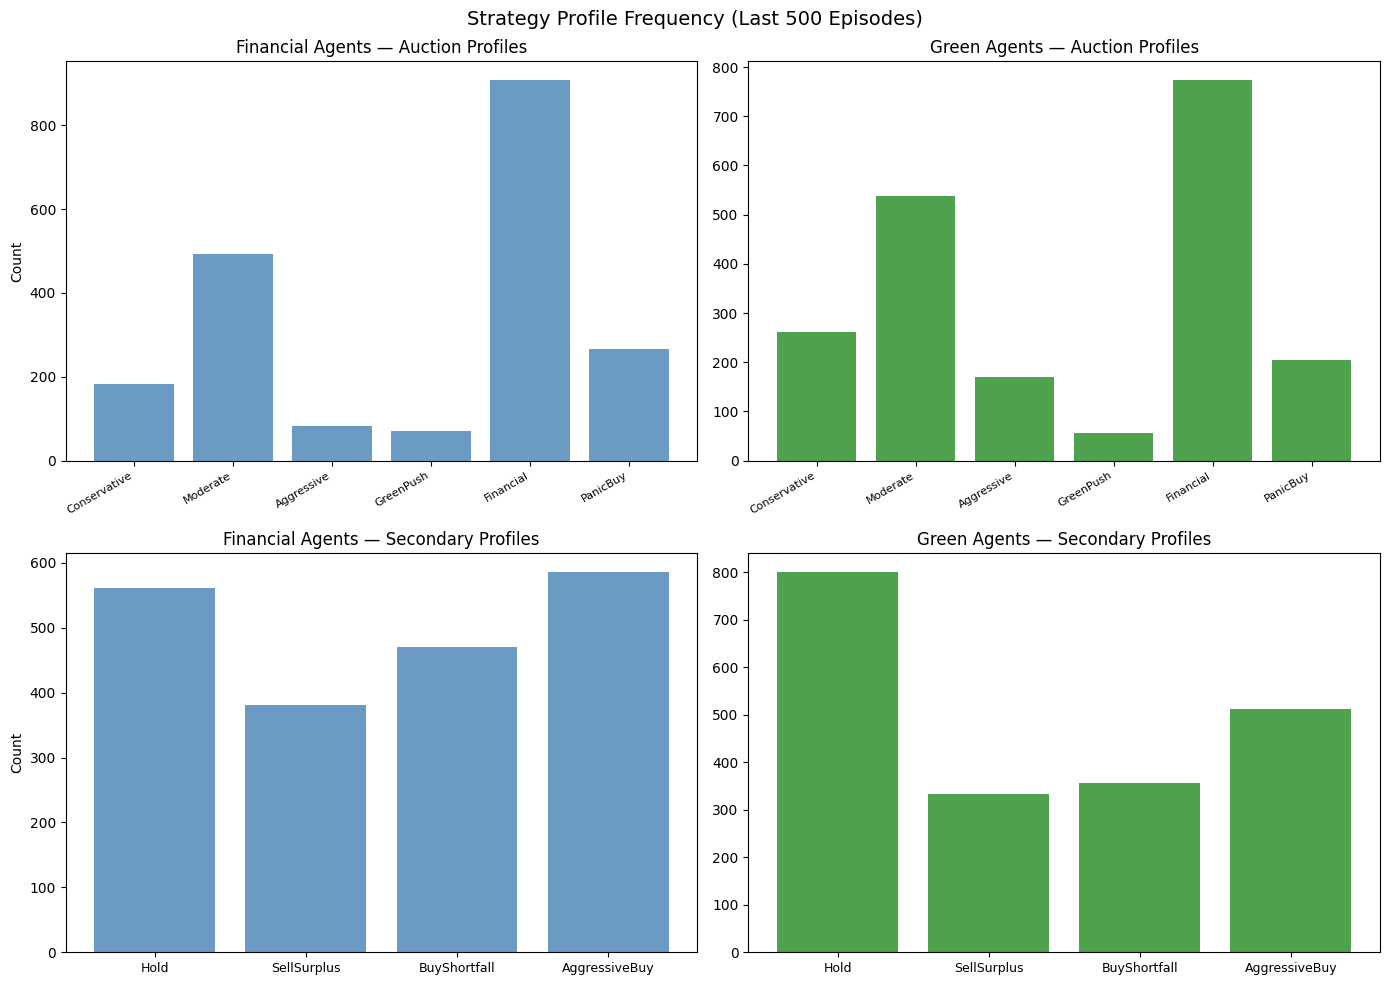

In [15]:
# Strategy frequency in last 500 episodes
plot_strategy_frequency(ql_df, n_agents, last_n=500)
plt.show()

## 9. Greedy Evaluation (100 Episodes)

In [16]:
if EVAL_AGENTS is not None and EVAL_CONFIG is not None:
    eval_results = evaluate_qlearning(
        EVAL_AGENTS, EVAL_CONFIG, seed=SEED,
        n_eval_episodes=100
    )
else:
    eval_results = None
    print('Skipped: evaluation requires trained agents or saved Q-tables.')


Q-Learning Evaluation — 100 greedy episodes
[ETSEnvironment] 8 learning + 4 bot = 12 total agents | cancel_under_subscribed=False

Evaluation Results (mean ± std over 100 episodes):
  Avg clearing price: 100.0 ± 2.4 €/t
  A1: reward=-5.73±2.57  green=38.3%  comply=94.3%  short=1.091Mt
  A2: reward=-6.41±2.10  green=33.3%  comply=95.0%  short=1.168Mt
  A3: reward=-1.20±1.22  green=52.7%  comply=93.2%  short=0.396Mt
  A4: reward=-0.90±0.75  green=52.5%  comply=98.6%  short=0.063Mt
  A5: reward=+2.72±0.60  green=87.4%  comply=99.8%  short=0.016Mt
  A6: reward=+2.26±0.69  green=77.6%  comply=97.9%  short=0.109Mt
  A7: reward=+3.98±0.32  green=99.9%  comply=98.3%  short=0.033Mt
  A8: reward=+3.65±0.46  green=99.0%  comply=94.8%  short=0.097Mt

  Eval log saved to results/qlearning/ql_eval_log_s42.csv


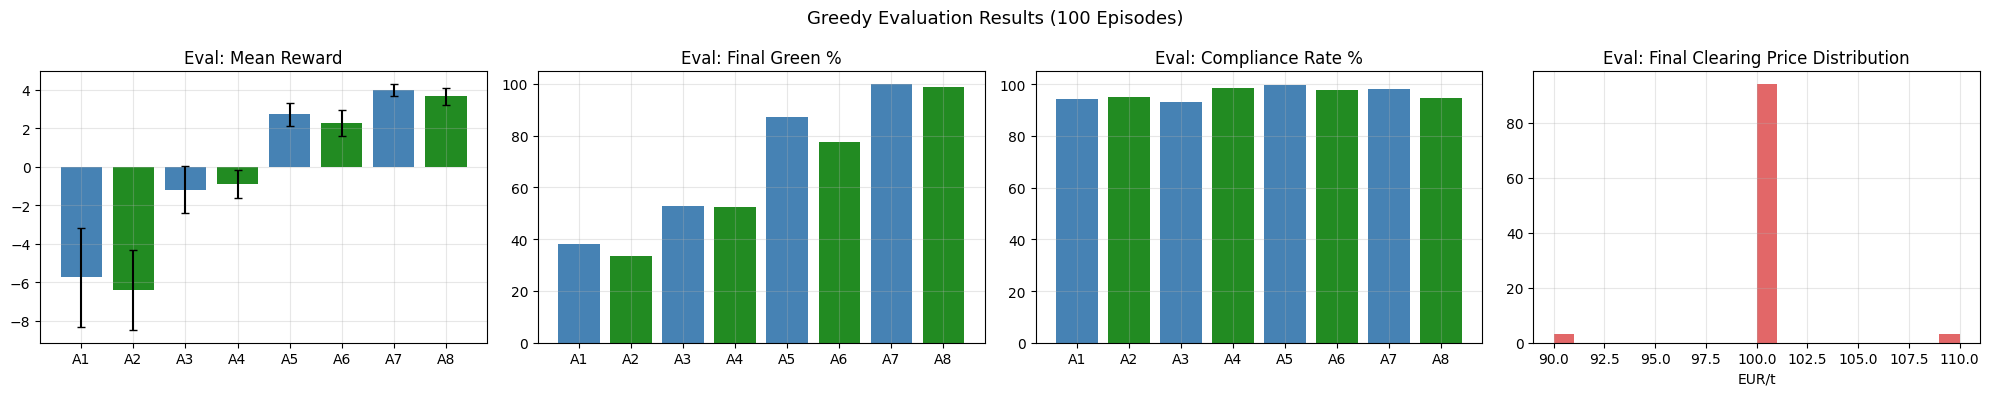

In [17]:
# Evaluation results visualization
if eval_results is not None:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # Rewards
    mean_rew = eval_results['rewards'].mean(axis=0)
    std_rew = eval_results['rewards'].std(axis=0)
    axes[0].bar(range(n_agents), mean_rew, yerr=std_rew, capsize=3,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[0].set_title('Eval: Mean Reward')
    axes[0].set_xticks(range(n_agents))
    axes[0].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[0].grid(True, alpha=0.3)

    # Green fracs
    mean_gf = eval_results['green_fracs'].mean(axis=0)
    axes[1].bar(range(n_agents), mean_gf * 100,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[1].set_title('Eval: Final Green %')
    axes[1].set_xticks(range(n_agents))
    axes[1].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[1].grid(True, alpha=0.3)

    # Compliance
    mean_comp = eval_results['compliance'].mean(axis=0)
    axes[2].bar(range(n_agents), mean_comp * 100,
                color=['steelblue' if i%2==0 else 'forestgreen' for i in range(n_agents)])
    axes[2].set_title('Eval: Compliance Rate %')
    axes[2].set_xticks(range(n_agents))
    axes[2].set_xticklabels([f'A{i+1}' for i in range(n_agents)])
    axes[2].set_ylim(0, 105)
    axes[2].grid(True, alpha=0.3)

    # Price distribution
    axes[3].hist(eval_results['prices'], bins=20, color='tab:red', alpha=0.7)
    axes[3].set_title('Eval: Final Clearing Price Distribution')
    axes[3].set_xlabel('EUR/t')
    axes[3].grid(True, alpha=0.3)

    plt.suptitle('Greedy Evaluation Results (100 Episodes)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print('Skipped: eval_results is not available.')

## 10. Comparison with PPO/HAPPO (if available)

Load PPO training logs and overlay the learning curves.

In [18]:
# Try to load PPO results for comparison
ppo_dir = 'results/'
ppo_log_path = os.path.join(ppo_dir, f'training_log_s{SEED}.csv')

if os.path.exists(ppo_log_path):
    ppo_df = pd.read_csv(ppo_log_path)
    print(f'PPO log loaded: {len(ppo_df)} episodes')
    HAS_PPO = True
else:
    print(f'PPO log not found at {ppo_log_path} - comparison plots will show Q-learning only.')
    print('Run PPO training first, then re-run this cell.')
    ppo_df = None
    HAS_PPO = False

PPO log loaded: 1500 episodes


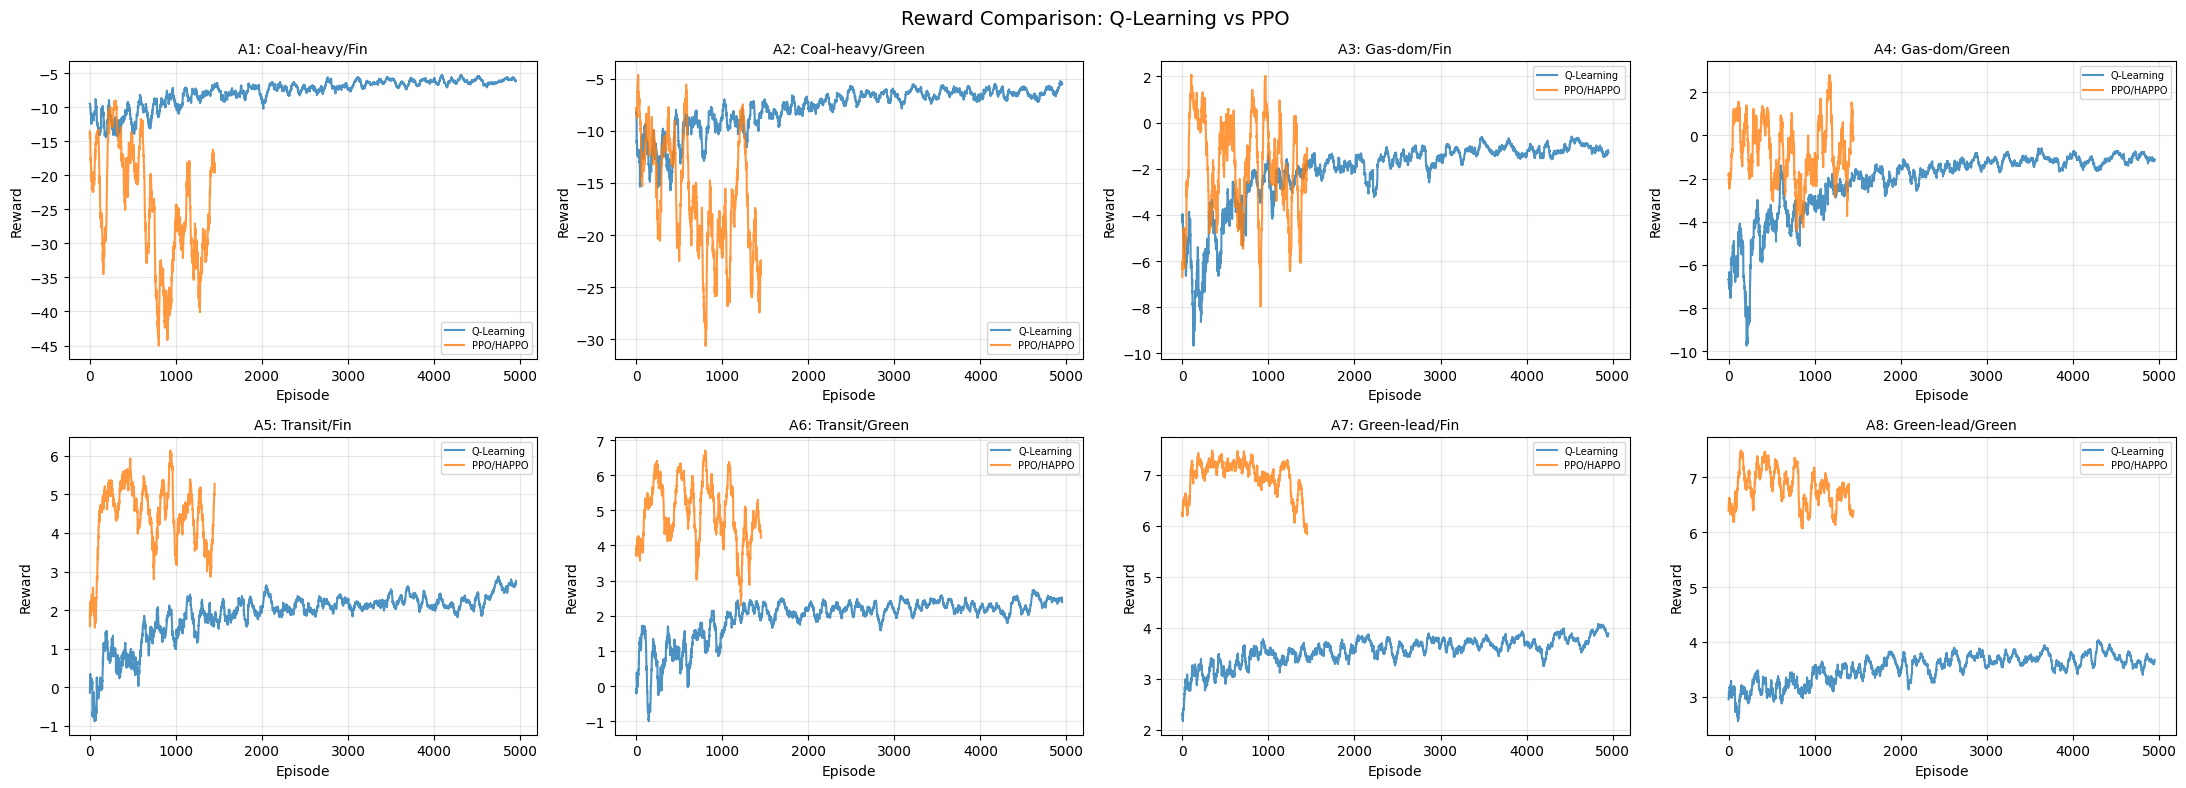

In [19]:
# Reward comparison
plot_reward_comparison(ql_df, ppo_df, n_agents)
plt.show()

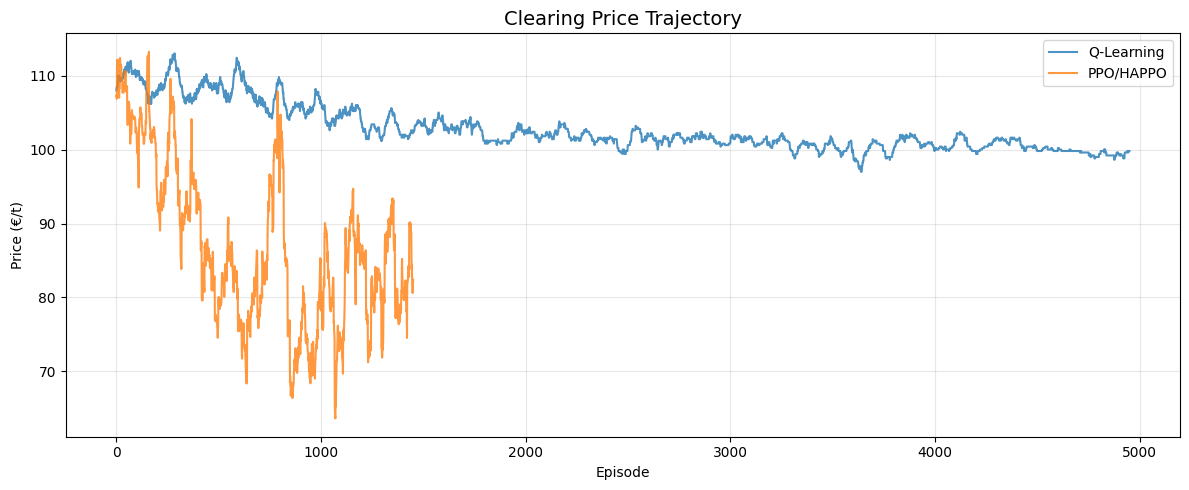

In [20]:
# Price comparison
plot_price_comparison(ql_df, ppo_df)
plt.show()

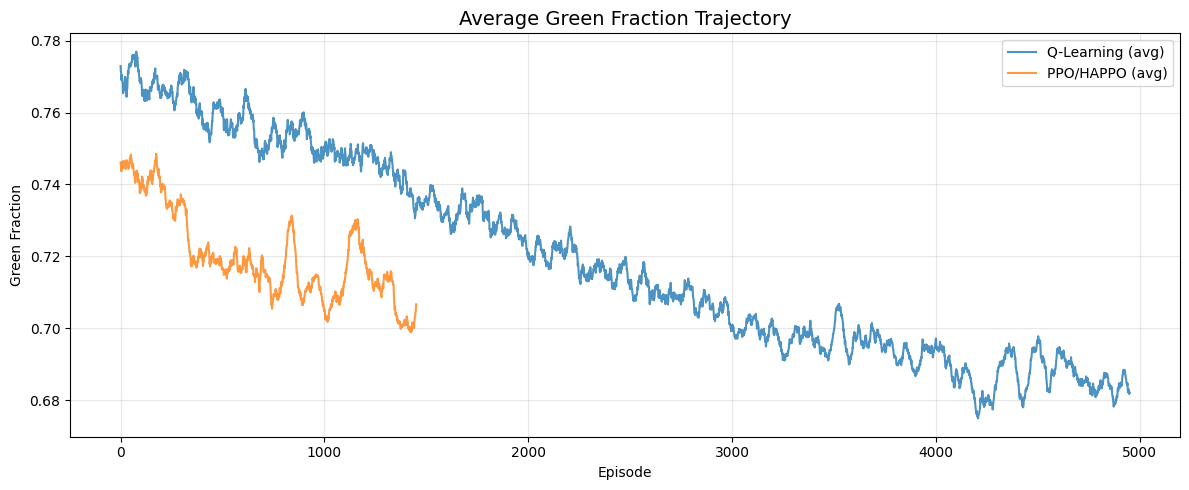

In [21]:
# Green fraction comparison
plot_green_comparison(ql_df, ppo_df, n_agents)
plt.show()

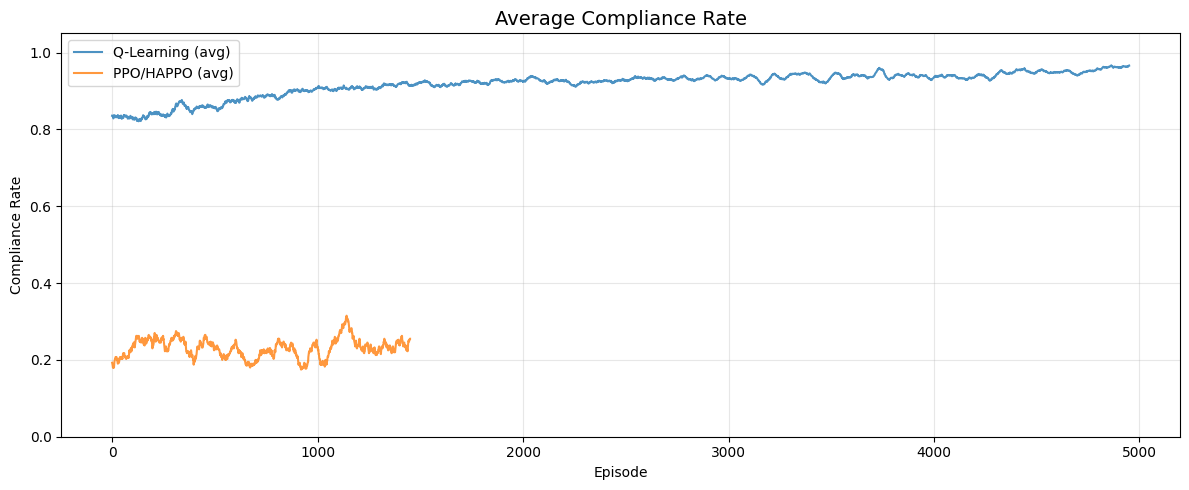

In [22]:
# Compliance comparison
plot_compliance_comparison(ql_df, ppo_df, n_agents)
plt.show()

## 11. Summary Statistics

In [23]:
# Final summary table
last_500 = ql_df.tail(500)

summary_data = []
for i in range(n_agents):
    row = {
        'Agent': f'A{i+1}',
        'Archetype': archetypes[i],
        'Avg Reward': last_500[f'reward_A{i+1}'].astype(float).mean(),
        'Final Green %': last_500[f'green_frac_A{i+1}'].astype(float).mean() * 100,
        'Compliance %': last_500[f'compliance_rate_A{i+1}'].astype(float).mean() * 100,
        'Avg Shortfall': last_500[f'shortfall_A{i+1}'].astype(float).mean(),
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print('Q-Learning Performance (last 500 training episodes):')
print(summary_df.to_string(index=False, float_format='%.2f'))

if HAS_PPO:
    print('\n--- For comparison, PPO (last 500 episodes): ---')
    ppo_last = ppo_df.tail(500)
    for i in range(n_agents):
        col_r = f'reward_A{i+1}'
        col_g = f'green_frac_A{i+1}'
        if col_r in ppo_last.columns:
            ppo_rew = ppo_last[col_r].astype(float).mean()
            ppo_gf = ppo_last[col_g].astype(float).mean() * 100 if col_g in ppo_last.columns else 0
            print(f'  A{i+1}: reward={ppo_rew:.2f}, green={ppo_gf:.1f}%')

Q-Learning Performance (last 500 training episodes):
Agent   Archetype  Avg Reward  Final Green %  Compliance %  Avg Shortfall
   A1    Coal/Fin       -6.14          35.26         92.48           1.04
   A2  Coal/Green       -6.25          35.85         91.71           1.24
   A3     Gas/Fin       -1.08          53.68         96.45           0.29
   A4   Gas/Green       -1.01          55.57         96.80           0.30
   A5   Trans/Fin        2.49          86.25         98.55           0.07
   A6 Trans/Green        2.40          83.71         98.14           0.10
   A7   Green/Fin        3.84          99.75         95.11           0.14
   A8 Green/Green        3.65          99.30         93.93           0.17

--- For comparison, PPO (last 500 episodes): ---
  A1: reward=-27.19, green=32.6%
  A2: reward=-18.73, green=40.4%
  A3: reward=-2.28, green=56.1%
  A4: reward=-0.44, green=59.2%
  A5: reward=4.20, green=90.1%
  A6: reward=4.47, green=90.9%
  A7: reward=6.71, green=99.9%
  A8: re

---

**Key Takeaways:**

- Q-learning with 243 states and 24 action profiles provides a tractable baseline
- The discretization necessarily loses information compared to PPO's continuous observations
- Comparison with PPO/HAPPO shows how much continuous-action deep RL gains over tabular methods
- This baseline helps quantify the "value of sophistication" in agent design for ETS markets